**Plan**
1. Filtrer soil Argentine
2. Filtrer stations Argentine Maize
3. Associer soil aux stations (buffer)
4. Construire signature pédologique station Argentine
5. Relier au yield Argentine
6. Tester Similarité Sol → Rendement

**STATION ID + coordonnées station**

* Mesurer rayon optimal (10 km vs 25 km vs 50 km)

* Tester stabilité du signal

* Identifier stations outliers

* Estimer yield pour stations sans données


Puis pour cette derniere etape :

* Pour une station sans yield :

* Calculer signature soil

* Trouver k stations les plus proches en espace pédologique

* Estimer yield = moyenne pondérée des voisins

* K-NN agro-écologique.

## **Les stations proches en signature pédologique ont des rendements similaires.**
**1.0 Similarité pédologique → Similarité de rendement**

C’est une hypothèse testable.

Méthode possible :

- Agréger sol par pays (ou climate zone)

- Standardiser features

- PCA

- KMeans ou clustering hiérarchique

- Identifier clusters de 

**2.0 Pays sans yield → estimation**

(transfert de connaissance.)
* Trouver pays cible (sans yield)

* Calculer distance pédologique aux autres pays

* Trouver k voisins les plus proches

* Estimer yield comme moyenne pondérée

* Like k-NN agro-écologique

Si 2.0 alors >> 
* cartographier les pays similaires
* identifier régimes agro-pédologiques globaux
* estimer rendement manquant
* identifier pays “outliers”


In [34]:
import pandas as pd
import geopandas as gpd

file_path = "/home/conite/Documents/WORKSPACE/PROJECTS/SoilHive/data/GygaArgentina.xlsx"
df_station = pd.read_excel(file_path, sheet_name="Station")

df_station["CROP_clean"] = (
    df_station["CROP"]
    .str.lower()
    .str.strip()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

def group_crop(crop):
    if "maize" in crop: return "maize"
    if "soybean" in crop: return "soybean"
    if "wheat" in crop: return "wheat"
    if "sunflower" in crop: return "sunflower"
    if "rice" in crop: return "rice"
    return "other"

df_station["CROP_GROUP"] = df_station["CROP_clean"].apply(group_crop)

df_maize = df_station[df_station["CROP_GROUP"] == "maize"].copy()

print("Stations maize :", df_maize["STATIONNAME"].nunique())

df_station["CROP_GROUP"].value_counts()

Stations maize : 32


/home/conite/anaconda3/envs/datamng/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


CROP_GROUP
soybean      90
maize        86
wheat        26
sunflower    12
rice          7
Name: count, dtype: int64

In [35]:
df_station["STATIONNAME"].nunique()

39

**3. GeoDataFrame Stations & Soil**

In [36]:
df_arg = pd.read_csv("/home/conite/Documents/WORKSPACE/PROJECTS/SoilHive/data/soil_argentina_with_country.csv")
df_arg


,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source,geometry,index_right,country
0,1986,-31.329722,-57.970000,CEC,cecph7,69.0,91.0,20.4,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.329722222222223),9.0,Argentina
1,1987,-31.329722,-57.970000,CEC,cecph7,51.0,69.0,27.9,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.329722222222223),9.0,Argentina
2,1988,-31.329722,-57.970000,CEC,cecph7,11.0,27.0,5.5,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.329722222222223),9.0,Argentina
3,1989,-31.329722,-57.970000,CEC,cecph7,0.0,11.0,6.6,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.329722222222223),9.0,Argentina
4,1990,-31.329722,-57.970000,CEC,cecph7,27.0,51.0,17.0,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.329722222222223),9.0,Argentina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28906,2709,-53.930000,-68.389722,occ,orgc,46.0,100.0,3.0,g/kg,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972222222222 -53.93),9.0,Argentina
28907,2710,-53.930000,-68.389722,clay,clay,10.0,34.0,24.0,g/100g,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972222222222 -53.93),9.0,Argentina
28908,2711,-53.930000,-68.389722,clay,clay,34.0,46.0,16.0,g/100g,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972222222222 -53.93),9.0,Argentina
28909,2712,-53.930000,-68.389722,clay,clay,0.0,10.0,22.0,g/100g,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972222222222 -53.93),9.0,Argentina


In [37]:
df_arg.columns

Index(['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm',
       'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license',
       'h3_index', 'publication_date', 'data_source', 'geometry',
       'index_right', 'country'],
      dtype='object')

In [38]:
df_maize

,STATIONNAME,LONGITUDE,LATITUDE,ELEVATION_METER,COUNTRY,CROP,YA,YW,YW-YA,YP,...,WPP,WPA,CROPPING_INTENSITY,YW_CV_TEMPORAL,YP_CV_TEMPORAL,YA_CV_TEMPORAL,CLIMATEZONE,AREA_IN_CLIMATEZONE_HA,CROP_clean,CROP_GROUP
0,Anguil,-63.990,-36.540,NaN,Argentina,- rainfed early maize,5.666998,9.117663,3.450664,14.633136,...,14.182610,8.815069,1,NaN,NaN,0.253639,5202,61949,rainfed early maize,maize
1,Azul,-59.833,-36.833,147.0,Argentina,- rainfed early maize,6.313167,14.101563,7.788396,17.162352,...,22.999626,10.296764,1,NaN,NaN,0.247518,5502,2604,rainfed early maize,maize
2,Balcarce,-58.298,-37.763,130.0,Argentina,- rainfed early maize,7.179566,14.119212,6.939647,17.436834,...,25.854541,13.146935,1,NaN,NaN,0.215995,5502,68143,rainfed early maize,maize
3,Bandera,-62.270,-28.890,NaN,Argentina,- rainfed early maize,6.957819,13.617850,6.660030,13.625666,...,16.897052,8.633274,1,NaN,NaN,0.115305,7202,312316,rainfed early maize,maize
4,Barrow,-60.217,-38.333,120.0,Argentina,- rainfed early maize,6.912167,9.799776,2.887610,13.117086,...,13.448885,9.486026,1,NaN,NaN,0.194356,5402,30110,rainfed early maize,maize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,Tandil,-59.230,-37.240,NaN,Argentina,Rainfed maize,6.624390,13.310287,6.685897,15.859560,...,21.095876,10.499196,1,NaN,NaN,0.133545,5502,42004,rainfed maize,maize
147,Venado Tuerto,-61.970,-33.750,NaN,Argentina,Rainfed maize,9.828395,16.058153,6.229758,16.622729,...,10.392865,6.360955,1,NaN,NaN,0.072433,6402,393581,rainfed maize,maize
148,Villa Maria del Rio,-63.680,-29.900,NaN,Argentina,Rainfed maize,7.204033,13.307111,6.103078,14.326183,...,24.049514,13.019617,1,NaN,NaN,0.140651,6302,383328,rainfed maize,maize
149,Villa Mercedes,-65.480,-33.720,NaN,Argentina,Rainfed maize,5.597656,13.077579,7.479923,13.475074,...,22.066830,9.445366,1,NaN,NaN,0.207698,6202,278615,rainfed maize,maize


In [39]:
df_maize.columns

Index(['STATIONNAME', 'LONGITUDE', 'LATITUDE', 'ELEVATION_METER', 'COUNTRY',
       'CROP', 'YA', 'YW', 'YW-YA', 'YP', 'YP-YA', 'WPP', 'WPA',
       'CROPPING_INTENSITY', 'YW_CV_TEMPORAL', 'YP_CV_TEMPORAL',
       'YA_CV_TEMPORAL', 'CLIMATEZONE', 'AREA_IN_CLIMATEZONE_HA', 'CROP_clean',
       'CROP_GROUP'],
      dtype='object')

In [44]:
df_maize

,STATIONNAME,LONGITUDE,LATITUDE,ELEVATION_METER,COUNTRY,CROP,YA,YW,YW-YA,YP,...,WPP,WPA,CROPPING_INTENSITY,YW_CV_TEMPORAL,YP_CV_TEMPORAL,YA_CV_TEMPORAL,CLIMATEZONE,AREA_IN_CLIMATEZONE_HA,CROP_clean,CROP_GROUP
0,Anguil,-63.990,-36.540,NaN,Argentina,- rainfed early maize,5.666998,9.117663,3.450664,14.633136,...,14.182610,8.815069,1,NaN,NaN,0.253639,5202,61949,rainfed early maize,maize
1,Azul,-59.833,-36.833,147.0,Argentina,- rainfed early maize,6.313167,14.101563,7.788396,17.162352,...,22.999626,10.296764,1,NaN,NaN,0.247518,5502,2604,rainfed early maize,maize
2,Balcarce,-58.298,-37.763,130.0,Argentina,- rainfed early maize,7.179566,14.119212,6.939647,17.436834,...,25.854541,13.146935,1,NaN,NaN,0.215995,5502,68143,rainfed early maize,maize
3,Bandera,-62.270,-28.890,NaN,Argentina,- rainfed early maize,6.957819,13.617850,6.660030,13.625666,...,16.897052,8.633274,1,NaN,NaN,0.115305,7202,312316,rainfed early maize,maize
4,Barrow,-60.217,-38.333,120.0,Argentina,- rainfed early maize,6.912167,9.799776,2.887610,13.117086,...,13.448885,9.486026,1,NaN,NaN,0.194356,5402,30110,rainfed early maize,maize
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,Tandil,-59.230,-37.240,NaN,Argentina,Rainfed maize,6.624390,13.310287,6.685897,15.859560,...,21.095876,10.499196,1,NaN,NaN,0.133545,5502,42004,rainfed maize,maize
147,Venado Tuerto,-61.970,-33.750,NaN,Argentina,Rainfed maize,9.828395,16.058153,6.229758,16.622729,...,10.392865,6.360955,1,NaN,NaN,0.072433,6402,393581,rainfed maize,maize
148,Villa Maria del Rio,-63.680,-29.900,NaN,Argentina,Rainfed maize,7.204033,13.307111,6.103078,14.326183,...,24.049514,13.019617,1,NaN,NaN,0.140651,6302,383328,rainfed maize,maize
149,Villa Mercedes,-65.480,-33.720,NaN,Argentina,Rainfed maize,5.597656,13.077579,7.479923,13.475074,...,22.066830,9.445366,1,NaN,NaN,0.207698,6202,278615,rainfed maize,maize


**3. GeoDataFrame Stations & Soil**

In [ ]:
gdf_station = gpd.GeoDataFrame(
    df_maize,
    geometry=gpd.points_from_xy(df_maize["LONGITUDE"], df_maize["LATITUDE"]),
    crs="EPSG:4326"
)

gdf_soil = gpd.GeoDataFrame(
    df_arg,
    geometry=gpd.points_from_xy(df_arg["lon"], df_arg["lat"]),
    crs="EPSG:4326"
)

In [41]:
gdf_soil

,id,lat,lon,property,original_name,upper_depth_cm,lower_depth_cm,value,unit,sampling_date,license,h3_index,publication_date,data_source,geometry,index_right,country
0,1986,-31.329722,-57.970000,CEC,cecph7,69.0,91.0,20.4,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.32972),9.0,Argentina
1,1987,-31.329722,-57.970000,CEC,cecph7,51.0,69.0,27.9,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.32972),9.0,Argentina
2,1988,-31.329722,-57.970000,CEC,cecph7,11.0,27.0,5.5,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.32972),9.0,Argentina
3,1989,-31.329722,-57.970000,CEC,cecph7,0.0,11.0,6.6,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.32972),9.0,Argentina
4,1990,-31.329722,-57.970000,CEC,cecph7,27.0,51.0,17.0,cmolc/kg,1992.0,CC BY 3.0,83c2cafffffffff,2023-01-01,WoSIS,POINT (-57.97 -31.32972),9.0,Argentina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28906,2709,-53.930000,-68.389722,occ,orgc,46.0,100.0,3.0,g/kg,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972 -53.93),9.0,Argentina
28907,2710,-53.930000,-68.389722,clay,clay,10.0,34.0,24.0,g/100g,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972 -53.93),9.0,Argentina
28908,2711,-53.930000,-68.389722,clay,clay,34.0,46.0,16.0,g/100g,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972 -53.93),9.0,Argentina
28909,2712,-53.930000,-68.389722,clay,clay,0.0,10.0,22.0,g/100g,1988.0,CC BY 3.0,83df6afffffffff,2023-01-01,WoSIS,POINT (-68.38972 -53.93),9.0,Argentina


**4. TEST MULTI-BUFFER ARGENTINE**

In [51]:
import geopandas as gpd
import pandas as pd

# Projection métrique
gdf_station_proj = gdf_station.to_crs(epsg=3857).copy()
gdf_soil_proj = gdf_soil.to_crs(epsg=3857).copy()

# Nettoyage colonnes parasites
for col in ["index_left", "index_right"]:
    if col in gdf_station_proj.columns:
        gdf_station_proj = gdf_station_proj.drop(columns=[col])
    if col in gdf_soil_proj.columns:
        gdf_soil_proj = gdf_soil_proj.drop(columns=[col])

total_soil_points = len(gdf_soil_proj)

results = []

for radius in [10, 25, 50]:
    
    station_buffer = gdf_station_proj.copy()
    station_buffer["geometry"] = station_buffer.buffer(radius * 1000)
    station_buffer = station_buffer.reset_index(drop=True)
    station_buffer["station_id"] = station_buffer.index
    
    for col in ["index_left", "index_right"]:
        if col in station_buffer.columns:
            station_buffer = station_buffer.drop(columns=[col])
    
    joined = gpd.sjoin(
        gdf_soil_proj,
        station_buffer[["station_id", "geometry"]],
        how="inner",
        predicate="within"
    )
    
    n_points = len(joined)
    coverage_pct = (n_points / total_soil_points) * 100
    
    points_per_station = joined.groupby("station_id").size()
    
    if len(points_per_station) == 0:
        continue
    
    results.append({
        "radius_km": radius,
        "total_soil_points": n_points,
        "coverage_percent": round(coverage_pct, 2),
        "stations_with_soil": len(points_per_station),
        "min_points_per_station": points_per_station.min(),
        "mean_points_per_station": round(points_per_station.mean(), 1),
        "max_points_per_station": points_per_station.max(),
        "std_points_per_station": round(points_per_station.std(), 1),
        "stations_>=100_points": (points_per_station >= 100).sum()
    })

df_buffer_analysis = pd.DataFrame(results)

df_buffer_analysis

,radius_km,total_soil_points,coverage_percent,stations_with_soil,min_points_per_station,mean_points_per_station,max_points_per_station,std_points_per_station,stations_>=100_points
0,10,3420,11.83,12,84,285.0,736,274.0,9
1,25,6300,21.79,27,32,233.3,962,267.0,21
2,50,12396,42.88,33,32,375.6,1432,401.4,27


buffer_Km = 25

In [53]:
gdf_station_proj = gdf_station.to_crs(epsg=3857).copy()
gdf_soil_proj = gdf_soil.to_crs(epsg=3857).copy()

gdf_station_proj["geometry"] = gdf_station_proj.buffer(25 * 1000)
gdf_station_proj = gdf_station_proj.reset_index(drop=True)
gdf_station_proj["station_id"] = gdf_station_proj.index

for col in ["index_left", "index_right"]:
    if col in gdf_station_proj.columns:
        gdf_station_proj = gdf_station_proj.drop(columns=[col])
    if col in gdf_soil_proj.columns:
        gdf_soil_proj = gdf_soil_proj.drop(columns=[col])


**5 Spatial Join Soil → Stations**

In [63]:
joined = gpd.sjoin(
    gdf_soil_proj,
    gdf_station_proj[["STATIONNAME", "geometry"]],
    how="inner",
    predicate="within"
)

print("Observations soil associées :", len(joined))

Observations soil associées : 6300


In [65]:
points_per_station = (
    joined
    .groupby("STATIONNAME")
    .size()
    .reset_index(name="n_soil_points")
    .sort_values("n_soil_points", ascending=False)
)

print(points_per_station)

print("\nStatistiques :")
print(points_per_station["n_soil_points"].describe())

  STATIONNAME  n_soil_points
0    Balcarce           2886
6   San Pedro            570
3   Pergamino            564
8    Villegas            516
2    La Dulce            516
5       Pilar            444
7      Tandil            420
1       Junin            288
4       Pigue             96

Statistiques :
count       9.000000
mean      700.000000
std       833.681594
min        96.000000
25%       420.000000
50%       516.000000
75%       564.000000
max      2886.000000
Name: n_soil_points, dtype: float64


**06 Signature pédologique par station (buffer_km = 25)**

In [66]:
soil_station = (
    joined
    .groupby(["STATIONNAME", "property"])["value"]
    .mean()
    .reset_index()
)

soil_pivot = soil_station.pivot(
    index="STATIONNAME",
    columns="property",
    values="value"
).reset_index()

print("Stations avec signature soil :", len(soil_pivot))

Stations avec signature soil : 9


* 9 stations argentines ont au moins un point soil dans un rayon de 25 km.

* Ces stations ont au moins une propriété mesurée

* Elles peuvent être utilisées pour la suite de l’analyse

**07. Agrégation Yield station**

In [68]:
yield_station = (
    df_maize
    .groupby("STATIONNAME")
    .agg({
        "YA": "mean",
        "YP": "mean",
        "YW": "mean"
    })
    .reset_index()
)

yield_station["yield_gap"] = yield_station["YP"] - yield_station["YA"]
yield_station

,STATIONNAME,YA,YP,YW,yield_gap
0,Anguil,5.218882,15.390107,10.881553,10.171225
1,Azul,6.011111,16.373058,13.849005,10.361947
2,Balcarce,6.806027,16.695118,14.449806,9.889091
3,Bandera,6.957819,13.625666,13.617850,6.667846
4,Barrow,6.588889,12.795784,10.162296,6.206895
5,General Pico,8.337044,14.816686,13.384008,6.479642
6,Gualeguaychú,5.594454,13.012074,11.465576,7.417620
7,Isca Yacu,7.476411,13.214904,12.866681,5.738492
8,Junin,9.054645,16.557991,15.900050,7.503346
9,La Dulce,6.600001,13.083007,9.541114,6.483005


**8.0 Merge Soil + Yield (Argentine)**

In [69]:
print("Stations avec soil :", soil_pivot["STATIONNAME"].nunique())
print("Stations avec yield :", yield_station["STATIONNAME"].nunique())

# Merge propre sur STATIONNAME
df_model = soil_pivot.merge(
    yield_station,
    on="STATIONNAME",
    how="inner"
)

print("Stations communes soil + yield :", df_model["STATIONNAME"].nunique())

Stations avec soil : 9
Stations avec yield : 32
Stations communes soil + yield : 9


* Sur 32 stations maize Argentine avec rendement,
* Seulement 9 ont suffisamment de points soil dans un rayon de 25 km.

**9.0 Standardisation + Clustering**

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

X = df_model.drop(columns=["STATIONNAME","YA","YP","YW","yield_gap"])
n_stations = len(X)
completeness = (
    X.notna().sum() / n_stations * 100
).sort_values(ascending=False)

completeness_df = completeness.reset_index()
completeness_df.columns = ["property", "percent_available"]

print(completeness_df)

          property  percent_available
0              CEC         100.000000
1              occ         100.000000
2               pH         100.000000
3             clay         100.000000
4                N         100.000000
5             sand         100.000000
6             silt         100.000000
7            CaCO3          44.444444
8               EC          22.222222
9               CF          11.111111
10              BD          11.111111
11  WR_gravimetric          11.111111
12               P          11.111111


* p < 0.05 → différence significative
* p > 0.05 → pas de différence détectée

In [124]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import f_oneway
import numpy as np

X = df_model.drop(columns=["STATIONNAME","YA","YP","YW","yield_gap"])

threshold = int(0.7 * len(X))
X = X.dropna(axis=1, thresh=threshold)
X = X.fillna(X.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def test_var(var):
    groups = [
        df_model[df_model["cluster"]==k][var]
        for k in df_model["cluster"].unique()
    ]
    f_stat, p_val = f_oneway(*groups)
    print(f"{var} p-value:", p_val)


In [125]:
df_model

,STATIONNAME,BD,CEC,CF,CaCO3,EC,N,P,WR_gravimetric,clay,occ,pH,sand,silt,YA,YP,YW,yield_gap,cluster
0,Balcarce,1.473407,21.866279,0.556818,143.153846,0.706667,1.665161,27.227273,22.375676,23.165000,15.147059,7.133871,43.642500,33.192500,6.806027,16.695118,14.449806,9.889091,2
1,Junin,NaN,18.414286,NaN,NaN,NaN,0.866667,NaN,NaN,15.857143,3.714286,6.842857,50.285714,33.857143,9.054645,16.557991,15.900050,7.503346,2
2,La Dulce,NaN,18.180000,NaN,NaN,NaN,1.400000,NaN,NaN,28.000000,13.000000,7.100000,42.000000,30.000000,6.600001,13.083007,9.541114,6.483005,2
3,Pergamino,NaN,21.683333,NaN,5.375000,0.100000,1.075000,NaN,NaN,24.583333,6.966667,6.983333,15.416667,60.000000,8.950785,16.096055,15.028200,7.145270,0
4,Pigue,NaN,39.500000,NaN,NaN,NaN,2.700000,NaN,NaN,29.000000,25.000000,8.000000,42.000000,29.000000,5.373927,13.444656,9.777254,8.070729,2
5,Pilar,NaN,4.150000,NaN,0.000000,NaN,0.400000,NaN,NaN,4.750000,2.000000,5.675000,85.083333,10.000000,7.846205,15.876138,15.557356,8.029934,1
6,San Pedro,NaN,23.920000,NaN,0.000000,NaN,1.225000,NaN,NaN,34.400000,7.200000,6.160000,5.400000,60.200000,8.385040,14.623471,14.053318,6.238431,0
7,Tandil,NaN,39.525000,NaN,NaN,NaN,1.050000,NaN,NaN,38.916667,5.750000,9.425000,24.416667,36.666667,6.624390,15.859560,13.310287,9.235170,3
8,Villegas,NaN,24.120000,NaN,NaN,NaN,0.500000,NaN,NaN,23.800000,3.000000,8.720000,11.933333,64.266667,8.427778,16.289332,14.294267,7.861555,0


In [127]:
print("Nombre d'observations :", X_scaled.shape[0])

Nombre d'observations : 2


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ----------------------------
# 1. Soil-only clustering
# ----------------------------

soil_cols = [
    "pH", "clay", "sand", "silt", "N", "CEC", "CaCO3", "EC"
]
X_soil = df_model[soil_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_soil)

silhouette_scores = []

K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Soil Only")
plt.show()

print("Best k:", K_range[np.argmax(silhouette_scores)])

ValueError: Number of labels is 2. Valid values are 2 to n_samples - 1 (inclusive)

In [122]:
nb_clusters = 3
kmeans = KMeans(n_clusters=nb_clusters, random_state=42)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

print("\nANOVA Results:") 
for var in ["YA","YP","YW","yield_gap"]:
    test_var(var)


ANOVA Results:
YA p-value: 0.4948124573824636
YP p-value: 0.7284767684881044
YW p-value: 0.4304387505473249
yield_gap p-value: 0.9184358844403683


In [123]:
nb_clusters = 4
kmeans = KMeans(n_clusters=nb_clusters, random_state=42)
df_model["cluster"] = kmeans.fit_predict(X_scaled)

print("\nANOVA Results:") 
for var in ["YA","YP","YW","yield_gap"]:
    test_var(var)


ANOVA Results:
YA p-value: 0.3764598827191367
YP p-value: 0.8992519135802723
YW p-value: 0.6376029797458713
yield_gap p-value: 0.5237311313286438


Les stations regroupées selon le sol n’ont pas des rendements réels significativement différents.

Possible raison :

Management domine

Irrigation

Variétés

Effet climat plus fort que sol

Dans l’échantillon Argentine station-level (n=9) :

La similarité pédologique locale n’explique pas significativement la structure du rendement.

In [109]:
X

,sand,clay,silt
0,43.642500,23.165000,33.192500
1,50.285714,15.857143,33.857143
2,42.000000,28.000000,30.000000
3,15.416667,24.583333,60.000000
4,42.000000,29.000000,29.000000
5,85.083333,4.750000,10.000000
6,5.400000,34.400000,60.200000
7,24.416667,38.916667,36.666667
8,11.933333,23.800000,64.266667


In [84]:
df_numeric = df_model.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
corr_matrix[["YA","YP","YW","yield_gap"]]

,YA,YP,YW,yield_gap
BD,NaN,NaN,NaN,NaN
CEC,-0.529709,-0.254413,-0.477265,0.276723
CF,NaN,NaN,NaN,NaN
CaCO3,-0.853520,0.683597,-0.320207,0.882508
EC,-1.000000,1.000000,-1.000000,1.000000
N,-0.741845,-0.587713,-0.706492,0.124428
P,NaN,NaN,NaN,NaN
WR_gravimetric,NaN,NaN,NaN,NaN
clay,-0.359974,-0.366773,-0.485254,-0.032390
occ,-0.795918,-0.611085,-0.756110,0.155630


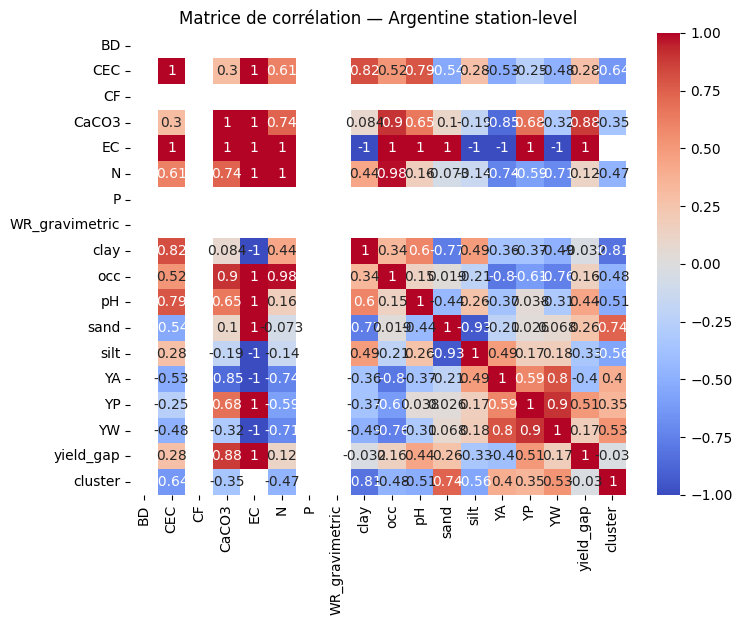

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Matrice de corrélation — Argentine station-level")
plt.show()

Une corrélation peut exister même si l’ANOVA était non significative ?

* cluster ↔ sand ≈ 0.74

* cluster ↔ clay ≈ -0.81

**YP (Potential Yield)**

YP dépend principalement du climat.

On observe : Corrélations plus faibles avec sol

Ce qui est logique YP n’est pas censé dépendre fortement du sol.

**YW montre des corrélations plus fortes avec texture :**

clay ↔ YW ≈ -0.49

sand ↔ YW ≈ 0.68


In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

features = ["sand", "clay", "silt"]

X = df_model[features].copy()
y = df_model["YW"].copy()

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print("R² explicatif (Texture → YW) :", round(r2, 3))

R² explicatif (Texture → YW) : 0.485


In [111]:
features = ["sand","clay","silt","CEC","occ","pH","N"]

X = df_model[features]
y = df_model["YW"]

mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2_full = r2_score(y, y_pred)
print("R² explicatif (7 propriétés → YW) :", round(r2_full,3))

R² explicatif (7 propriétés → YW) : 0.792


**Trouver pays similaires à l’Argentine (global)**

In [93]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

DATA_DIR = Path('../data')
SOIL_PATH = DATA_DIR / 'combined_output_data_points.csv'

df = pd.read_csv(SOIL_PATH)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326'
)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

world = world[['ADMIN', 'geometry']].rename(columns={'ADMIN':'country'})
df_global = gpd.sjoin(gdf, world, how='left', predicate='intersects')
print("Colonnes disponibles après jointure :")
print(df_global.columns)

Colonnes disponibles après jointure :
Index(['id', 'lat', 'lon', 'property', 'original_name', 'upper_depth_cm',
       'lower_depth_cm', 'value', 'unit', 'sampling_date', 'license',
       'h3_index', 'publication_date', 'data_source', 'geometry',
       'index_right', 'country'],
      dtype='object')


In [96]:
# Nettoyage minimal
df_global = df_global.dropna(subset=["country","property","value"])

soil_country = (
    df_global
    .groupby(["country","property"])["value"]
    .mean()
    .reset_index()
)

soil_pivot = soil_country.pivot(
    index="country",
    columns="property",
    values="value"
)

# On garde propriétés robustes
key_props = ["sand","clay","silt","CEC","occ","pH","N"]

soil_pivot = soil_pivot[key_props].dropna()

2 - Standardiser

In [97]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(soil_pivot)

soil_scaled = pd.DataFrame(
    X_scaled,
    index=soil_pivot.index,
    columns=soil_pivot.columns
)

3 - Similarité cosinus

In [98]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(soil_scaled)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=soil_scaled.index,
    columns=soil_scaled.index
)

arg_sim = similarity_df.loc["Argentina"].sort_values(ascending=False)

arg_sim = arg_sim.drop("Argentina")

print("Pays les plus similaires à l'Argentine :")
print(arg_sim.head(10))

Pays les plus similaires à l'Argentine :
country
Spain       0.937441
Hungary     0.902209
Mexico      0.858120
Italy       0.747895
India       0.730235
Ecuador     0.632295
Pakistan    0.575612
Honduras    0.575413
Russia      0.507984
Bolivia     0.414939
Name: Argentina, dtype: float64


### Est ce qu'on observe les meme similitudes avec les yields ? 

Station → Moyenne multi-annuelle
Puis
Pays → Moyenne des stations

In [106]:
df_station["CROP_clean"] = (
    df_station["CROP"]
    .str.lower()
    .str.strip()
    .str.replace("-", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
)

df_station["CROP_GROUP"] = df_station["CROP_clean"].apply(
    lambda x: "maize" if "maize" in x else "other"
)

df_maize_station = df_station[df_station["CROP_GROUP"] == "maize"].copy()

# Moyenne multi-annuelle par station
yield_station = (
    df_maize_station
    .groupby(["COUNTRY","STATIONNAME"])
    .agg({
        "YA":"mean",
        "YP":"mean",
        "YW":"mean"
    })
    .reset_index()
)

yield_station["yield_gap"] = yield_station["YP"] - yield_station["YA"]

In [107]:
yield_country_station = (
    yield_station
    .groupby("COUNTRY")
    .agg({
        "YA":"mean",
        "YP":"mean",
        "YW":"mean",
        "yield_gap":"mean"
    })
)